# Analisis Exploratorio de Datos


**Fuentes analizadas:**

1. <span style="color:#A6373F">co_transacciones_habi.csv</span> - transacciones internas de Habi
2. <span style="color:#A6373F">macro_housing_index.xml</span> - índice mensual de precios de vivienda (CO / IN / USA)
3. <span style="color:#A6373F">usa_transactions_page_01.json</span> - transacciones de EE.UU., API paginada
4. API REST pública <span style="color:#A6373F">https://data.ny.gov/resource/yv49-emnc.json</span> - subastas de bienes raíces excedentes del estado de NY

## Librerías

In [2]:
#uv add numpy pandas matplotlib requests
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import requests
import xml.etree.ElementTree as ET

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4)


In [3]:
RUTA_FUENTES = Path("../fuentes")

RUTA_CSV = RUTA_FUENTES / "co_transacciones_habi.csv"
RUTA_XML = RUTA_FUENTES / "macro_housing_index.xml"
RUTA_JSON = RUTA_FUENTES / "usa_transactions_page_01.json"
URL_API_NY = "https://data.ny.gov/resource/yv49-emnc.json"

### Analisis de la fuente de datos: co_transacciones_habi.csv

Transacciones inmobiliarias internas de Habi en Colombia (COP).

In [6]:
df_csv = pd.read_csv(RUTA_CSV)
print(f"Filas: {len(df_csv):,}  |  Columnas: {df_csv.shape[1]}")
df_csv.head()


Filas: 45,901  |  Columnas: 11


,id,ciudad,tipo,area_m2,alcobas,banos,precio_cop,lat,lon,fecha,estado
0,CO038760,SANTA MARTA,Casa,109.6,2,3,416700000.0,6.235260,-75.549642,2024-02-28,publicada
1,CO043235,SANTA MARTA,Casa,128.7,3,2,487600000.0,4.588845,-74.035797,2024-06-22,vendida
2,C1023947,VALLEDUPAR,Casa,128.7,3,2,487600000.0,4.588845,-74.035797,2024-06-22,vendida
3,CO004450,MEDELLIN,Casa,176.7,2,2,200000000.0,6.198647,-75.559899,2024-04-10,comprada
4,CO025197,BOGOTA,Apartamento,77.8,2,2,159700000.0,4.660761,-74.049764,2024-10-11,publicada


In [7]:
df_csv.dtypes

id                str
ciudad            str
tipo              str
area_m2       float64
alcobas         int64
banos           int64
precio_cop    float64
lat           float64
lon           float64
fecha             str
estado            str
dtype: object

In [8]:
# Valores nulos / vacios por columna
df_csv.isna().sum().to_frame("nulos")


,nulos
id,0
ciudad,0
tipo,0
area_m2,0
alcobas,0
banos,0
precio_cop,367
lat,0
lon,0
fecha,0


In [9]:
# Estadisticas descriptivas de las columnas numericas
df_csv[["area_m2", "alcobas", "banos", "precio_cop", "lat", "lon"]].describe()


,area_m2,alcobas,banos,precio_cop,lat,lon
count,45901.000000,45901.000000,45901.000000,4.553400e+04,45901.000000,45901.000000
mean,120.378959,2.497767,1.804863,1.673050e+08,6.325676,-75.239490
std,41.506757,0.957086,0.750848,7.300924e+07,2.856540,0.900573
min,28.000000,1.000000,1.000000,6.000000e+01,3.370009,-76.589992
25%,91.700000,2.000000,1.000000,1.160000e+08,4.581747,-75.637888
50%,120.400000,3.000000,2.000000,1.605000e+08,4.719747,-74.868369
75%,148.600000,3.000000,2.000000,2.116000e+08,6.309317,-74.168074
max,305.500000,4.000000,3.000000,5.678000e+08,11.049997,-74.030001


In [10]:
# Categorias ciudad, tipo, estado
for columna in ["ciudad", "tipo", "estado"]:
    print(f"--- {columna} ({df_csv[columna].nunique()} valores unicos) ---")
    print(df_csv[columna].value_counts(), "\n")


--- ciudad (13 valores unicos) ---
ciudad
Santiago de Cali    5752
Barranquilla        5737
B/quilla            5682
Cali                5564
Medellin            3914
MEDELLIN            3805
Medellín            3795
Bogotá              2994
BOGOTA              2919
Bogota D.C.         2913
Bogota              2823
SANTA MARTA            2
VALLEDUPAR             1
Name: count, dtype: int64 

--- tipo (4 valores unicos) ---
tipo
Apartaestudio    11578
Casa             11451
Local            11442
Apartamento      11430
Name: count, dtype: int64 

--- estado (4 valores unicos) ---
estado
publicada       18274
vendida         11561
comprada         9228
remodelacion     6838
Name: count, dtype: int64 



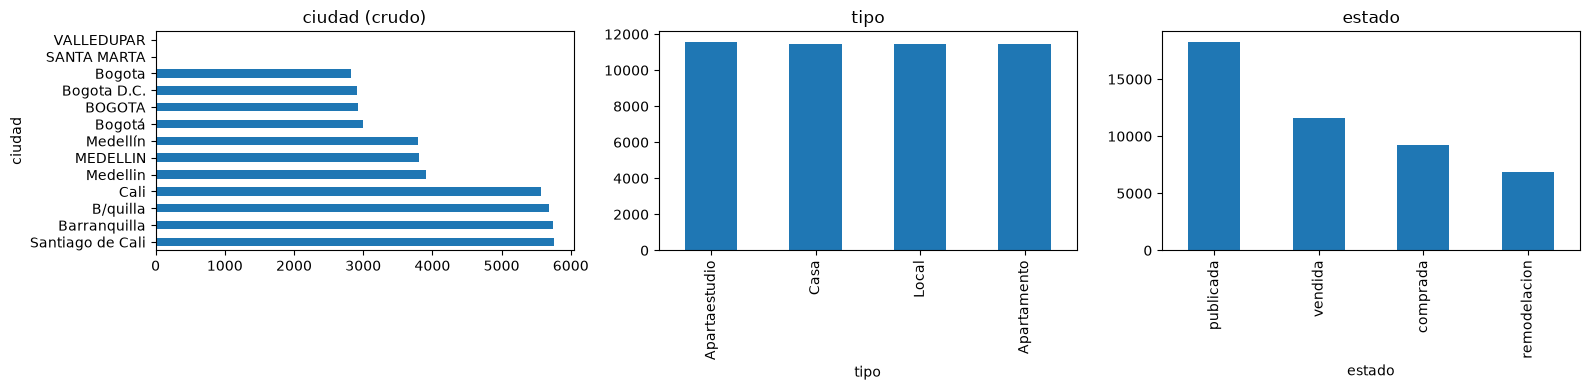

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df_csv["ciudad"].value_counts().plot(kind="barh", ax=axes[0], title="ciudad (crudo)")
df_csv["tipo"].value_counts().plot(kind="bar", ax=axes[1], title="tipo")
df_csv["estado"].value_counts().plot(kind="bar", ax=axes[2], title="estado")
plt.tight_layout()
plt.show()


In [66]:
# Rango de fechas
fechas = pd.to_datetime(df_csv["fecha"], errors="coerce")
print("Rango de fecha:", fechas.min(), "->", fechas.max())
print("Fechas no parseables:", fechas.isna().sum())


Rango de fecha: 2024-01-01 00:00:00 -> 2024-12-28 00:00:00
Fechas no parseables: 0


### Periodicidad de las fechas de transaccion

Buscamos si las transacciones se registran con una cadencia regular (diaria, semanal, mensual, trimestral) o de forma irregular.


In [ ]:
#contamos transacciones por dia y medimos el intervalo
fechas_validas = fechas.dropna().dt.normalize()
conteo_diario = fechas_validas.value_counts().sort_index()

print(f"Dias distintos con transacciones: {conteo_diario.shape[0]:,}")
print("Rango:", conteo_diario.index.min().date(), "->", conteo_diario.index.max().date())

intervalos = conteo_diario.index.to_series().diff().dt.days.dropna()
print("Distribucion de intervalos (en dias) entre fechas consecutivas con transacciones:")
print(intervalos.value_counts().sort_index())


Dias distintos con transacciones: 336
Rango: 2024-01-01 -> 2024-12-28
Distribucion de intervalos (en dias) entre fechas consecutivas con transacciones:
fecha
1.0    324
2.0      1
3.0      4
4.0      6
Name: count, dtype: int64


In [70]:
# Duplicados por id
conteo_id = df_csv["id"].value_counts()
ids_duplicados = conteo_id[conteo_id > 1]
print(f"IDs que se repiten: {len(ids_duplicados)} (de {df_csv['id'].nunique():,} ids unicos)")
ids_duplicados.head(10)


IDs que se repiten: 900 (de 45,001 ids unicos)


id
CO021119    2
CO044237    2
CO040898    2
CO012058    2
CO021850    2
CO021448    2
CO008459    2
CO014714    2
CO034602    2
CO005618    2
Name: count, dtype: int64

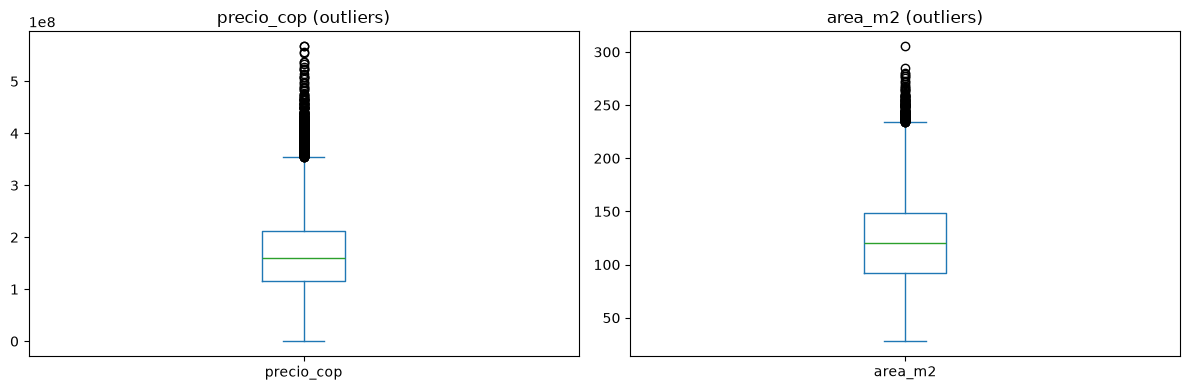

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_csv["precio_cop"].dropna().plot(kind="box", ax=axes[0], title="precio_cop (outliers)")
df_csv["area_m2"].plot(kind="box", ax=axes[1], title="area_m2 (outliers)")
plt.tight_layout()
plt.show()


### Analisis de la fuente de datos: macro_housing_index.xml

Indice mensual de precios de vivienda por pais.

In [15]:
root = ET.parse(RUTA_XML).getroot()
unidad = root.get("unit")

filas_xml = []
for pais in root.iter("country"):
    nombre_pais = pais.get("name")
    for obs in pais.iter("observation"):
        filas_xml.append({
            "country": nombre_pais,
            "month": obs.findtext("month"),
            "price_index": float(obs.findtext("price_index")),
        })

df_xml = pd.DataFrame(filas_xml)
df_xml["month"] = pd.to_datetime(df_xml["month"], format="%Y-%m")
print(f"Unidad: {unidad}  |  Filas: {len(df_xml)}  |  Paises: {df_xml['country'].unique().tolist()}")
df_xml.head()


Unidad: index_100_base  |  Filas: 36  |  Paises: ['Colombia', 'India', 'USA']


,country,month,price_index
0,Colombia,2024-01-01,100.20
1,Colombia,2024-02-01,100.86
2,Colombia,2024-03-01,101.19
3,Colombia,2024-04-01,102.43
4,Colombia,2024-05-01,103.23


In [16]:
df_xml.groupby("country")["price_index"].describe()


,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Colombia,12.0,103.345000,1.949967,100.20,102.1200,103.45,104.8375,106.21
India,12.0,103.191667,1.811784,100.32,101.8750,103.39,104.8225,105.73
USA,12.0,103.183333,1.963875,99.78,101.6775,103.09,104.4875,106.04


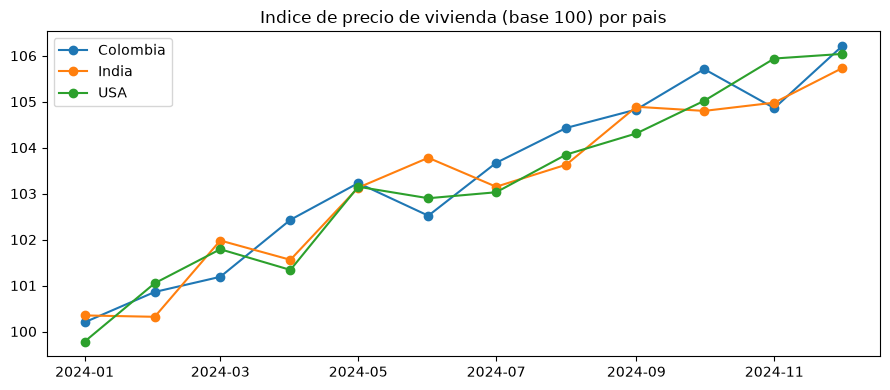

In [17]:
fig, ax = plt.subplots()
for pais, grupo in df_xml.groupby("country"):
    ax.plot(grupo["month"], grupo["price_index"], marker="o", label=pais)
ax.set_title("Indice de precio de vivienda (base 100) por pais")
ax.legend()
plt.tight_layout()
plt.show()


### Analisis de la fuente de datos: usa_transactions_page_01.json

Transacciones de EEUU

In [25]:
# Cargamos todas las paginas
paginas = sorted(RUTA_FUENTES.glob("usa_transactions_page_*.json"))
frames = []
for ruta_pagina in paginas:
    with open(ruta_pagina, "r", encoding="utf-8") as f:
        pagina = json.load(f)
    frames.append(pd.json_normalize(pagina["data"], sep="_"))

if frames:
    df_json_completo = pd.concat(frames, ignore_index=True)
    print(f"Paginas encontradas: {len(paginas)}  |  Filas totales: {len(df_json_completo):,}")

Paginas encontradas: 6  |  Filas totales: 6,000


In [18]:
with open(RUTA_JSON, "r", encoding="utf-8") as f:
    contenido_json = json.load(f)

print("meta:", contenido_json["meta"])
df_json = pd.json_normalize(contenido_json["data"], sep="_")
print(f"Filas en esta pagina: {len(df_json)}  |  Columnas: {df_json.shape[1]}")
df_json.head()


meta: {'page': 1, 'total_pages': 6, 'next': 'usa_transactions_page_02.json'}
Filas en esta pagina: 1000  |  Columnas: 9


,transaction_id,transaction_type,transaction_date,lease_rate,authority_name,property_state,property_fair_market_value,property_type,sale_price
0,US00000,Lease,2024-06-01,290.0,Regional Dev Corp,FL,580428,Residential,NaN
1,US00001,Lease,0024-06-18,349.0,State Land Office,FL,698799,Land,NaN
2,US00002,Lease,2024-10-10,243.0,State Land Office,NJ,486360,Land,NaN
3,US00003,Lease,2024-06-09,272.0,State Land Office,TX,543723,Residential,NaN
4,US00004,Lease,2024-02-27,262.0,Regional Dev Corp,TX,524870,Land,NaN


In [26]:
df_json = df_json_completo
df_json.head()

,transaction_id,transaction_type,transaction_date,lease_rate,authority_name,property_state,property_fair_market_value,property_type,sale_price
0,US00000,Lease,2024-06-01,290.0,Regional Dev Corp,FL,580428,Residential,NaN
1,US00001,Lease,0024-06-18,349.0,State Land Office,FL,698799,Land,NaN
2,US00002,Lease,2024-10-10,243.0,State Land Office,NJ,486360,Land,NaN
3,US00003,Lease,2024-06-09,272.0,State Land Office,TX,543723,Residential,NaN
4,US00004,Lease,2024-02-27,262.0,Regional Dev Corp,TX,524870,Land,NaN


In [27]:
df_json.dtypes


transaction_id                    str
transaction_type                  str
transaction_date                  str
lease_rate                    float64
authority_name                    str
property_state                    str
property_fair_market_value     object
property_type                     str
sale_price                    float64
dtype: object

In [28]:
df_json.isna().sum().to_frame("nulos")


,nulos
transaction_id,0
transaction_type,0
transaction_date,0
lease_rate,3927
authority_name,0
property_state,0
property_fair_market_value,0
property_type,0
sale_price,2438


In [29]:
df_json[["property_fair_market_value", "lease_rate"]].describe()


,lease_rate
count,2073.000000
mean,210.550410
std,75.486776
min,40.000000
25%,157.000000
50%,210.000000
75%,264.000000
max,464.000000


In [30]:
for columna in ["property_state", "property_type", "transaction_type"]:
    print(f"--- {columna} ---")
    print(df_json[columna].value_counts(), "\n")


--- property_state ---
property_state
FL    1572
NJ    1514
TX    1468
NY    1446
Name: count, dtype: int64 

--- property_type ---
property_type
Residential    2042
Land           2017
Commercial     1941
Name: count, dtype: int64 

--- transaction_type ---
transaction_type
Lease       2073
Purchase    1976
Sale        1951
Name: count, dtype: int64 



In [31]:
# revisamos las fechas deberían de empezar con 2024
anios = df_json["transaction_date"].str.slice(0, 4)
print(anios.value_counts())
print("\nEjemplos con anio anomalo (probable typo/formato invalido en la fuente):")
df_json.loc[anios != "2024", ["transaction_id", "transaction_date"]].head()


transaction_date
2024    4831
0024    1169
Name: count, dtype: int64

Ejemplos con anio anomalo (probable typo/formato invalido en la fuente):


,transaction_id,transaction_date
1,US00001,0024-06-18
8,US00008,0024-11-18
12,US00012,0024-02-07
23,US00023,0024-08-20
34,US00034,0024-05-13


### Análisis de la fuente de datos: data.ny.gov/resource/yv49-emnc.json

subastas de bienes raices excedentes del estado de NY.

In [33]:
def descargar_api(url_base, limit_pagina=1000, max_paginas=20):
    registros = []
    offset = 0
    for _ in range(max_paginas):
        resp = requests.get(
            url_base,
            params={"$limit": limit_pagina, "$offset": offset},
            timeout=30,
        )
        resp.raise_for_status()
        pagina = resp.json()
        if not pagina:
            break
        registros.extend(pagina)
        if len(pagina) < limit_pagina:
            break
        offset += limit_pagina
    return registros


In [35]:
registros_ny = descargar_api(URL_API_NY)
df_api = pd.DataFrame(registros_ny)
print(f"Filas descargadas: {len(df_api):,}  |  Columnas: {df_api.shape[1]}")
df_api.head()

Filas descargadas: 41  |  Columnas: 5


,property,auction_date,minimum_bid,final_bid,status
0,"10.80 ± Acres Vacant Land, on the west side of...",0023-12-12T00:00:00.000,130000,163000,Sold
1,1.2+ acres of vacant land on Warners Road in t...,0023-10-17T00:00:00.000,8500,15100,Sold
2,"210 Miles Avenue, Syracuse, NY",0022-10-27T00:00:00.000,160000,215000,Sold
3,"Walter J. Mahoney State Office Building, Buffa...",0021-10-07T00:00:00.000,750000,4100000,Sold
4,"1471 Teller Avenue, Bronx, New York",0021-09-29T00:00:00.000,380000,690000,Sold


In [36]:
df_api.dtypes


property        str
auction_date    str
minimum_bid     str
final_bid       str
status          str
dtype: object

In [37]:
df_api.isna().sum().to_frame("nulos")


,nulos
property,0
auction_date,0
minimum_bid,0
final_bid,0
status,0


In [38]:
print(df_api["status"].value_counts())


status
Sold    41
Name: count, dtype: int64


In [40]:
# Casteo de los tipos de datos
df_api_num = df_api.copy()
df_api_num["minimum_bid"] = pd.to_numeric(df_api_num["minimum_bid"], errors="coerce")
df_api_num["final_bid"] = pd.to_numeric(df_api_num["final_bid"], errors="coerce")
df_api_num[["minimum_bid", "final_bid"]].describe()


,minimum_bid,final_bid
count,4.100000e+01,4.100000e+01
mean,2.179878e+05,4.718220e+05
std,4.672808e+05,8.936663e+05
min,2.500000e+03,3.993000e+03
25%,2.500000e+04,4.600000e+04
50%,9.500000e+04,1.650000e+05
75%,2.000000e+05,3.900000e+05
max,2.850000e+06,4.100000e+06


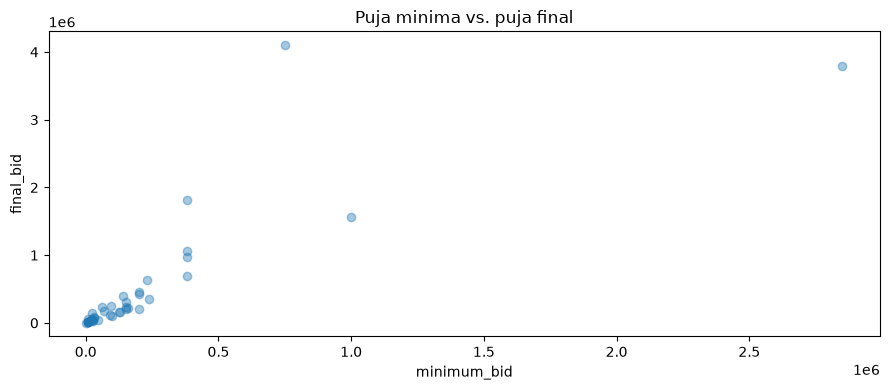

In [41]:
fig, ax = plt.subplots()
ax.scatter(df_api_num["minimum_bid"], df_api_num["final_bid"], alpha=0.4)
ax.set_xlabel("minimum_bid")
ax.set_ylabel("final_bid")
ax.set_title("Puja minima vs. puja final")
plt.tight_layout()
plt.show()


In [43]:
#Revisamos los años de las fechas
print(df_api["auction_date"].head(10))

anio_crudo = df_api["auction_date"].str.slice(0, 4).astype(int)
print("\nRango de año tal como llega de la API:", anio_crudo.min(), "-", anio_crudo.max())

#Corregimos los años de las fechas
auction_date_corregida = pd.to_datetime(
    (anio_crudo + 2000).astype(str) + df_api["auction_date"].str.slice(4), errors="coerce"
)
print("Rango de fecha corregido:", auction_date_corregida.min(), "->", auction_date_corregida.max())


0    0023-12-12T00:00:00.000
1    0023-10-17T00:00:00.000
2    0022-10-27T00:00:00.000
3    0021-10-07T00:00:00.000
4    0021-09-29T00:00:00.000
5    0021-08-18T00:00:00.000
6    0021-06-15T00:00:00.000
7    0021-06-15T00:00:00.000
8    0020-09-15T00:00:00.000
9    0020-02-18T00:00:00.000
Name: auction_date, dtype: str

Rango de año tal como llega de la API: 15 - 23
Rango de fecha corregido: 2015-05-28 00:00:00 -> 2023-12-12 00:00:00


### Resumen comparativo de las 4 fuentes

In [48]:
resumen_fuentes = pd.DataFrame([
    {
        "fuente": "co_transacciones_habi.csv",
        "formato": "CSV",
        "filas": len(df_csv),
        "columnas": df_csv.shape[1],
        "pais/moneda": "Colombia / COP"
        
    },
    {
        "fuente": "macro_housing_index.xml",
        "formato": "XML",
        "filas": len(df_xml),
        "columnas": df_xml.shape[1],
        "pais/moneda": "CO / IN / USA"
    },
    {
        "fuente": "usa_transactions_page_01.json",
        "formato": "JSON paginado",
        "filas": len(df_json),
        "columnas": df_json_completo.shape[1],
        "pais/moneda": "USA / USD"
    },
    {
        "fuente": "API data.ny.gov",
        "formato": "JSON via API REST (SODA)",
        "filas": len(df_api),
        "columnas": df_api.shape[1],
        "pais/moneda": "USA (NY) / USD"
    },
])
resumen_fuentes


,fuente,formato,filas,columnas,pais/moneda
0,co_transacciones_habi.csv,CSV,45901,11,Colombia / COP
1,macro_housing_index.xml,XML,36,3,CO / IN / USA
2,usa_transactions_page_01.json,JSON paginado,6000,9,USA / USD
3,API data.ny.gov,JSON via API REST (SODA),41,5,USA (NY) / USD


## Transformaciones para la fuente de datos: co_transacciones_habi.csv


In [49]:
df = df_csv.copy()


### Normalizacion de ciudad

In [50]:
print(df["ciudad"].value_counts())


ciudad
Santiago de Cali    5752
Barranquilla        5737
B/quilla            5682
Cali                5564
Medellin            3914
MEDELLIN            3805
Medellín            3795
Bogotá              2994
BOGOTA              2919
Bogota D.C.         2913
Bogota              2823
SANTA MARTA            2
VALLEDUPAR             1
Name: count, dtype: int64


In [52]:
MAPA_CIUDADES = {
    "BOGOTA": "Bogota",
    "Bogota": "Bogota",
    "Bogota D.C.": "Bogota",
    "Bogotá": "Bogota",
    "MEDELLIN": "Medellin",
    "Medellin": "Medellin",
    "Medellín": "Medellin",
    "Cali": "Cali",
    "Santiago de Cali": "Cali",
    "Barranquilla": "Barranquilla",
    "B/quilla": "Barranquilla",
}

df["ciudad_normalizada"] = df["ciudad"].str.strip().map(MAPA_CIUDADES).fillna(
    df["ciudad"].str.strip().str.title()
)
print(f"Ciudades antes:  {df['ciudad'].nunique()}")
print(f"Ciudades despues: {df['ciudad_normalizada'].nunique()}")
df["ciudad_normalizada"].value_counts()


Ciudades antes:  13
Ciudades despues: 6


ciudad_normalizada
Bogota          11649
Medellin        11514
Barranquilla    11419
Cali            11316
Santa Marta         2
Valledupar          1
Name: count, dtype: int64

### Normalizacion de texto tipo y estado

In [53]:
print("tipo:", df["tipo"].unique())
print("estado:", df["estado"].unique())

df["tipo_normalizado"] = df["tipo"].str.strip().str.title()
df["estado_normalizado"] = df["estado"].str.strip().str.lower()


tipo: <StringArray>
['Casa', 'Apartamento', 'Apartaestudio', 'Local']
Length: 4, dtype: str
estado: <StringArray>
['publicada', 'vendida', 'comprada', 'remodelacion']
Length: 4, dtype: str


### Casteo de columnas numericas

In [55]:
columnas_numericas = ["area_m2", "alcobas", "banos", "precio_cop", "lat", "lon"]
for columna in columnas_numericas:
    convertida = pd.to_numeric(df[columna], errors="coerce")
    fallidas = convertida.isna().sum() - df[columna].isna().sum()
    print(f"{columna:12s} -> Errores en la conversión: {fallidas}")


area_m2      -> Errores en la conversión: 0
alcobas      -> Errores en la conversión: 0
banos        -> Errores en la conversión: 0
precio_cop   -> Errores en la conversión: 0
lat          -> Errores en la conversión: 0
lon          -> Errores en la conversión: 0


### Parseo de fecha

In [56]:
df["fecha_parseada"] = pd.to_datetime(df["fecha"], errors="coerce")
print("Fallos de parseo:", df["fecha_parseada"].isna().sum() - df["fecha"].isna().sum())
print("Rango:", df["fecha_parseada"].min(), "->", df["fecha_parseada"].max())


Fallos de parseo: 0
Rango: 2024-01-01 00:00:00 -> 2024-12-28 00:00:00


### Nulos en precio_cop (variable de Predicción)

In [59]:
sin_precio = df["precio_cop"].isna() | (df["precio_cop"].astype(str).str.strip() == "")
print(f"Filas sin precio_cop: {sin_precio.sum()} de {len(df):,} ({sin_precio.mean():.3%})")
df.loc[sin_precio, ["id", "ciudad", "precio_cop"]].head()


Filas sin precio_cop: 367 de 45,901 (0.800%)


,id,ciudad,precio_cop
263,CO006089,Cali,NaN
368,CO026735,BOGOTA,NaN
483,CO017384,B/quilla,NaN
673,CO003175,Medellín,NaN
754,CO012287,Bogotá,NaN


### Duplicados columna id
Nos quedamos con una sola fila

In [60]:
conteo_id = df["id"].value_counts()
ids_repetidos = conteo_id[conteo_id > 1]
print(f"IDs repetidos: {len(ids_repetidos)} (afectan {ids_repetidos.sum():,} filas)")

#validamos si las filas repetidas son identicas o difieren entre si
ejemplo_id = ids_repetidos.index[0]
df[df["id"] == ejemplo_id]


IDs repetidos: 900 (afectan 1,800 filas)


,id,ciudad,tipo,area_m2,alcobas,banos,precio_cop,lat,lon,fecha,estado,ciudad_normalizada,tipo_normalizado,estado_normalizado,fecha_parseada
20,CO021119,Bogotá,Apartamento,78.3,3,1,103600000.0,4.650549,-74.064806,2024-09-10,vendida,Bogota,Apartamento,vendida,2024-09-10
14488,CO021119,Bogotá,Apartamento,78.3,3,1,103600000.0,4.650549,-74.064806,2024-09-10,vendida,Bogota,Apartamento,vendida,2024-09-10


### Outliers en precio_cop y area_m2

Se revisan los extremos con el criterio de rango intercuartil (IQR)

In [65]:
def limites_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


for columna in ["precio_cop", "area_m2"]:
    serie = pd.to_numeric(df[columna], errors="coerce").dropna()
    lim_inf, lim_sup = limites_iqr(serie)
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    print(f"{columna}: limites IQR = [{lim_inf:,.0f}, {lim_sup:,.0f}]  |  outliers: {len(outliers)}")
    print("  minimo:", serie.min(), " maximo:", serie.max())


precio_cop: limites IQR = [-27,400,000, 355,000,000]  |  outliers: 615
  minimo: 60.0  maximo: 567800000.0
area_m2: limites IQR = [6, 234]  |  outliers: 148
  minimo: 28.0  maximo: 305.5
